# Scriptorium Parser Benchmark Findings

This notebook summarizes the CSE 195 document parsing benchmark for the RefAIned / Scriptorium project.

The goal is to compare multiple PDF parsing strategies for scientific papers and evaluate how well they support downstream retrieval-augmented generation workflows.

This notebook is not for parser installation or debugging. It assumes the parser framework has already been set up and that the parser wrappers are available under `parsers/`.

## Benchmark Scope

The benchmark currently evaluates 9 local parsers:

1. PyMuPDF
2. pdfplumber
3. PyPDF
4. Tika
5. Unstructured
6. Docling
7. Marker
8. MinerU
9. GROBID

These parsers represent different extraction categories:

- **Flat text baselines:** PyMuPDF, pdfplumber, PyPDF
- **Semi-structured extraction:** Tika
- **Structure-aware document parsing:** Unstructured, Docling, Marker, MinerU
- **Structured academic metadata extraction:** GROBID

In [4]:
from pathlib import Path
import sys
import os
import pandas as pd

ROOT = Path.cwd()
INPUTS = ROOT / "inputs"
OUTPUTS = ROOT / "outputs"

PDF_PATH = INPUTS / "slam_llm.pdf"
RUN_OUTPUTS = OUTPUTS / PDF_PATH.stem
PARSER_OUTPUTS = RUN_OUTPUTS / "parser_outputs"

print("Current directory:", ROOT)
print("Python executable:", sys.executable)
print("Input PDF:", PDF_PATH)
print("PDF exists:", PDF_PATH.exists())
print("Parser output directory:", PARSER_OUTPUTS)
print("Parser output directory exists:", PARSER_OUTPUTS.exists())

Current directory: /home/jovyan
Python executable: /opt/conda/bin/python
Input PDF: /home/jovyan/inputs/slam_llm.pdf
PDF exists: True
Parser output directory: /home/jovyan/outputs/slam_llm/parser_outputs
Parser output directory exists: True


## Parser Framework Check

The refactored parser framework uses:

- `parsers/core/base.py` for shared parser result types and validation
- `parsers/core/registry.py` for parser registration
- `parsers/core/runner.py` for benchmark execution
- `parsers/implementations/` for individual parser wrappers

Each parser exposes a common `extract(pdf_path)` interface and returns a standardized `ParserResult`.

In [5]:
from parsers import PARSER_SPECS

print("Registered parsers:")
for name, spec in PARSER_SPECS.items():
    print(f"- {name}: {spec.category} | requires: {', '.join(spec.requires) if spec.requires else 'none'}")

Registered parsers:
- pymupdf: flat_text | requires: none
- pdfplumber: flat_text | requires: none
- pypdf: flat_text | requires: none
- tika: semi_structured | requires: tika, java
- unstructured: structure_aware | requires: unstructured
- mineru: structure_aware | requires: mineru CLI
- docling: structure_aware | requires: docling
- marker: structure_aware | requires: marker-pdf
- grobid: structured_metadata | requires: GROBID server at localhost:8070


## Start GROBID Server Before Running the Benchmark

GROBID must be running before the benchmark cell is executed.

Open a **Terminal** in JupyterHub and copy/paste the following commands:

```bash
cd /home/jovyan/grobid-0.9.0
export JAVA_HOME=/opt/conda
export PATH=$JAVA_HOME/bin:$PATH
./gradlew :grobid-service:run
```

Leave this terminal running while the benchmark notebook runs.

Then return to this notebook and run the next cell to confirm GROBID is alive.

In [6]:
import requests

url = "http://localhost:8070/api/isalive"

try:
    response = requests.get(url, timeout=10)
    print("GROBID status:", response.status_code)
    print("GROBID response:", response.text)

    if response.status_code != 200:
        raise RuntimeError("GROBID is reachable but did not return status 200.")

except Exception as exc:
    raise RuntimeError(
        "GROBID is not running. Open a Terminal and run the GROBID startup commands "
        "from the previous Markdown cell before running the benchmark."
    ) from exc

GROBID status: 200
GROBID response: true


## Run the 9-Parser Benchmark

This cell runs the stable 9-parser benchmark.

Important: GROBID must already be running at `localhost:8070` before this cell is executed.

In [7]:
from parsers import run_parsers, PARSER_SPECS

SELECTED_PARSERS = [
    "pymupdf",
    "pdfplumber",
    "pypdf",
    "tika",
    "unstructured",
    "docling",
    "marker",
    "mineru",
    "grobid",
]

print("Selected parsers:", SELECTED_PARSERS)

missing_from_registry = [
    parser_name
    for parser_name in SELECTED_PARSERS
    if parser_name not in PARSER_SPECS
]

if missing_from_registry:
    raise ValueError(f"These selected parsers are not registered: {missing_from_registry}")

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Input PDF not found: {PDF_PATH}")

parser_outputs, parser_status = run_parsers(
    PDF_PATH,
    output_dir=PARSER_OUTPUTS,
    selected=SELECTED_PARSERS,
)

df_parser_status = pd.DataFrame(parser_status)

status_path = RUN_OUTPUTS / "parser_status.csv"
RUN_OUTPUTS.mkdir(parents=True, exist_ok=True)
df_parser_status.to_csv(status_path, index=False)

print("Saved parser status to:", status_path)
print("Successful parsers:", list(parser_outputs.keys()))

df_parser_status

Selected parsers: ['pymupdf', 'pdfplumber', 'pypdf', 'tika', 'unstructured', 'docling', 'marker', 'mineru', 'grobid']


/opt/conda/lib/python3.12/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
No languages specified, defaulting to English.
[INFO] 2026-05-05 22:41:41,605 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-05 22:41:41,608 [RapidOCR] download_file.py:60: File exists and is valid: /opt/conda/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-05 22:41:41,609 [RapidOCR] main.py:57: Using /opt/conda/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-05 22:41:41,652 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-05 22:41:41,653 [RapidOCR] download_file.py:60: File exists and is valid: /opt/conda/lib/p

Saved parser status to: /home/jovyan/outputs/slam_llm/parser_status.csv
Successful parsers: ['pymupdf', 'pdfplumber', 'pypdf', 'tika', 'unstructured', 'docling', 'marker', 'mineru', 'grobid']


,parser,status,chars,runtime_seconds,type,requires,error,output_path
0,pymupdf,success,88199,0.09,flat_text,,,/home/jovyan/outputs/slam_llm/parser_outputs/p...
1,pdfplumber,success,85465,1.74,flat_text,,,/home/jovyan/outputs/slam_llm/parser_outputs/p...
2,pypdf,success,88394,0.54,flat_text,,,/home/jovyan/outputs/slam_llm/parser_outputs/p...
3,tika,success,90660,0.09,semi_structured,"tika, java",,/home/jovyan/outputs/slam_llm/parser_outputs/t...
4,unstructured,success,95836,4.56,structure_aware,unstructured,,/home/jovyan/outputs/slam_llm/parser_outputs/u...
5,docling,success,100840,10.34,structure_aware,docling,,/home/jovyan/outputs/slam_llm/parser_outputs/d...
6,marker,success,102133,40.50,structure_aware,marker-pdf,,/home/jovyan/outputs/slam_llm/parser_outputs/m...
7,mineru,success,88200,31.92,structure_aware,mineru CLI,,/home/jovyan/outputs/slam_llm/parser_outputs/m...
8,grobid,success,69846,2.02,structured_metadata,GROBID server at localhost:8070,,/home/jovyan/outputs/slam_llm/parser_outputs/g...


## Benchmark Status Summary

This section summarizes which parsers succeeded, how much text each produced, and how long each parser took.

In [13]:
status_path = RUN_OUTPUTS / "parser_status.csv"

df_status = pd.read_csv(status_path)

display(df_status)

success_count = (df_status["status"] == "success").sum()
total_count = len(df_status)

print(f"Successful parsers: {success_count}/{total_count}")

df_status[["parser", "status", "chars", "runtime_seconds", "type", "output_path"]]

,parser,status,chars,runtime_seconds,type,requires,error,output_path
0,pymupdf,success,88199,0.09,flat_text,NaN,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/p...
1,pdfplumber,success,85465,1.74,flat_text,NaN,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/p...
2,pypdf,success,88394,0.54,flat_text,NaN,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/p...
3,tika,success,90660,0.09,semi_structured,"tika, java",NaN,/home/jovyan/outputs/slam_llm/parser_outputs/t...
4,unstructured,success,95836,4.56,structure_aware,unstructured,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/u...
5,docling,success,100840,10.34,structure_aware,docling,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/d...
6,marker,success,102133,40.50,structure_aware,marker-pdf,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/m...
7,mineru,success,88200,31.92,structure_aware,mineru CLI,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/m...
8,grobid,success,69846,2.02,structured_metadata,GROBID server at localhost:8070,NaN,/home/jovyan/outputs/slam_llm/parser_outputs/g...


Successful parsers: 9/9


,parser,status,chars,runtime_seconds,type,output_path
0,pymupdf,success,88199,0.09,flat_text,/home/jovyan/outputs/slam_llm/parser_outputs/p...
1,pdfplumber,success,85465,1.74,flat_text,/home/jovyan/outputs/slam_llm/parser_outputs/p...
2,pypdf,success,88394,0.54,flat_text,/home/jovyan/outputs/slam_llm/parser_outputs/p...
3,tika,success,90660,0.09,semi_structured,/home/jovyan/outputs/slam_llm/parser_outputs/t...
4,unstructured,success,95836,4.56,structure_aware,/home/jovyan/outputs/slam_llm/parser_outputs/u...
5,docling,success,100840,10.34,structure_aware,/home/jovyan/outputs/slam_llm/parser_outputs/d...
6,marker,success,102133,40.50,structure_aware,/home/jovyan/outputs/slam_llm/parser_outputs/m...
7,mineru,success,88200,31.92,structure_aware,/home/jovyan/outputs/slam_llm/parser_outputs/m...
8,grobid,success,69846,2.02,structured_metadata,/home/jovyan/outputs/slam_llm/parser_outputs/g...


In [14]:
df_success = df_status[df_status["status"] == "success"].copy()

summary = df_success[["parser", "type", "chars", "runtime_seconds", "output_path"]].sort_values(
    by="runtime_seconds"
)

summary

,parser,type,chars,runtime_seconds,output_path
0,pymupdf,flat_text,88199,0.09,/home/jovyan/outputs/slam_llm/parser_outputs/p...
3,tika,semi_structured,90660,0.09,/home/jovyan/outputs/slam_llm/parser_outputs/t...
2,pypdf,flat_text,88394,0.54,/home/jovyan/outputs/slam_llm/parser_outputs/p...
1,pdfplumber,flat_text,85465,1.74,/home/jovyan/outputs/slam_llm/parser_outputs/p...
8,grobid,structured_metadata,69846,2.02,/home/jovyan/outputs/slam_llm/parser_outputs/g...
4,unstructured,structure_aware,95836,4.56,/home/jovyan/outputs/slam_llm/parser_outputs/u...
5,docling,structure_aware,100840,10.34,/home/jovyan/outputs/slam_llm/parser_outputs/d...
7,mineru,structure_aware,88200,31.92,/home/jovyan/outputs/slam_llm/parser_outputs/m...
6,marker,structure_aware,102133,40.50,/home/jovyan/outputs/slam_llm/parser_outputs/m...


## Parser Output Inventory

Each parser writes a normalized `.txt` output into `outputs/slam_llm/parser_outputs/`.

Some structure-aware parsers also produce artifact folders:

- `docling_run/`
- `marker_run/`
- `mineru_run_txt/`

These artifact folders preserve parser-specific outputs such as Markdown files, JSON metadata, extracted images, layout PDFs, or intermediate files.

In [15]:
from pathlib import Path

print("Parser output files and folders:")

for path in sorted(PARSER_OUTPUTS.iterdir()):
    if path.name == ".ipynb_checkpoints":
        continue

    if path.is_dir():
        file_count = sum(1 for item in path.rglob("*") if item.is_file())
        print(f"[DIR]  {path.name} ({file_count} files)")
    else:
        size_kb = path.stat().st_size / 1024
        print(f"[FILE] {path.name} ({size_kb:.1f} KB)")

Parser output files and folders:
[FILE] docling.txt (98.6 KB)
[DIR]  docling_run (1 files)
[FILE] grobid.txt (68.3 KB)
[FILE] marker.txt (99.9 KB)
[DIR]  marker_run (7 files)
[FILE] mineru.txt (86.8 KB)
[DIR]  mineru_run_txt (30 files)
[FILE] pdfplumber.txt (84.1 KB)
[FILE] pymupdf.txt (86.8 KB)
[FILE] pypdf.txt (87.0 KB)
[FILE] tika.txt (89.3 KB)
[FILE] unstructured.txt (94.2 KB)


## Character Count Comparison

Character count gives a rough sense of how much text each parser extracted from the same PDF.

This is not a direct quality score. A higher character count can mean better coverage, but it can also include repeated text, noisy OCR, references, captions, or formatting artifacts.

In [16]:
char_summary = df_status[df_status["status"] == "success"].copy()

char_summary = char_summary[["parser", "type", "chars"]].sort_values(
    by="chars",
    ascending=False,
)

char_summary

,parser,type,chars
6,marker,structure_aware,102133
5,docling,structure_aware,100840
4,unstructured,structure_aware,95836
3,tika,semi_structured,90660
2,pypdf,flat_text,88394
7,mineru,structure_aware,88200
0,pymupdf,flat_text,88199
1,pdfplumber,flat_text,85465
8,grobid,structured_metadata,69846


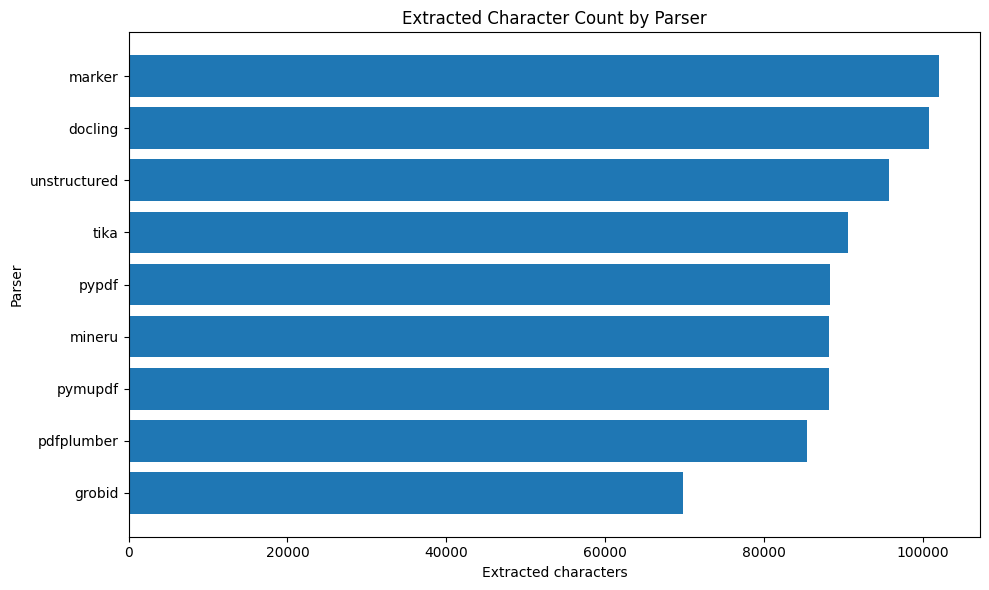

In [17]:
import matplotlib.pyplot as plt

plot_df = char_summary.sort_values(by="chars", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["parser"], plot_df["chars"])
plt.xlabel("Extracted characters")
plt.ylabel("Parser")
plt.title("Extracted Character Count by Parser")
plt.tight_layout()
plt.show()

## Runtime Comparison

Runtime shows the tradeoff between simple text extraction and heavier structure-aware parsing.

The flat text parsers are generally fastest. Structure-aware parsers take longer because they may perform layout analysis, OCR, artifact generation, model inference, or server-based processing.

In [18]:
runtime_summary = df_status[df_status["status"] == "success"].copy()

runtime_summary = runtime_summary[["parser", "type", "runtime_seconds"]].sort_values(
    by="runtime_seconds",
    ascending=True,
)

runtime_summary

,parser,type,runtime_seconds
0,pymupdf,flat_text,0.09
3,tika,semi_structured,0.09
2,pypdf,flat_text,0.54
1,pdfplumber,flat_text,1.74
8,grobid,structured_metadata,2.02
4,unstructured,structure_aware,4.56
5,docling,structure_aware,10.34
7,mineru,structure_aware,31.92
6,marker,structure_aware,40.50


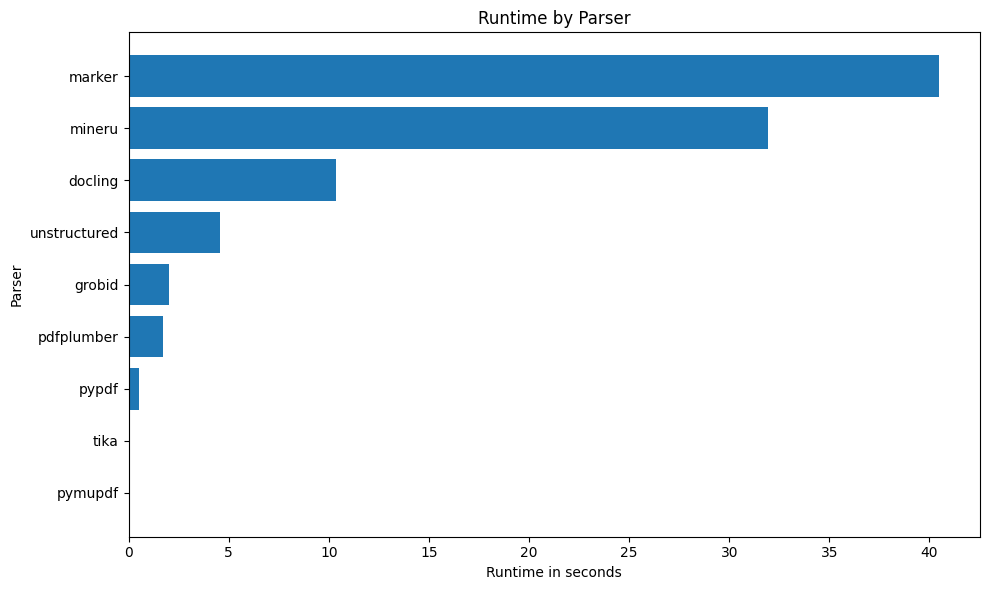

In [19]:
plot_df = runtime_summary.sort_values(by="runtime_seconds", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["parser"], plot_df["runtime_seconds"])
plt.xlabel("Runtime in seconds")
plt.ylabel("Parser")
plt.title("Runtime by Parser")
plt.tight_layout()
plt.show()

## Preview Each Parser Output

This section previews the beginning of each normalized parser output.

The goal is to quickly inspect qualitative differences in formatting, structure, section preservation, and extraction noise.

In [20]:
from pathlib import Path

def preview_parser_output(parser_name: str, max_chars: int = 1200):
    output_path = PARSER_OUTPUTS / f"{parser_name}.txt"

    if not output_path.exists():
        print(f"[missing] {output_path}")
        return

    text = output_path.read_text(encoding="utf-8", errors="ignore")

    print("=" * 100)
    print(f"{parser_name.upper()} OUTPUT PREVIEW")
    print("=" * 100)
    print(f"Path: {output_path}")
    print(f"Characters: {len(text)}")
    print("-" * 100)
    print(text[:max_chars])
    print("\n")

In [21]:
for parser_name in SELECTED_PARSERS:
    preview_parser_output(parser_name, max_chars=1200)

PYMUPDF OUTPUT PREVIEW
Path: /home/jovyan/outputs/slam_llm/parser_outputs/pymupdf.txt
Characters: 88199
----------------------------------------------------------------------------------------------------

--- PAGE 1 ---
JOURNAL OF LATEX CLASS FILES, VOL. 14, NO. 8, AUGUST 2021
1
SLAM-LLM: A Modular, Open-Source Multimodal
Large Language Model Framework and Best Practice
for Speech, Language, Audio and Music Processing
Ziyang Ma, Guanrou Yang, Wenxi Chen, Zhifu Gao, Yexing Du, Xiquan Li, Zhisheng Zheng, Haina Zhu, Jianheng
Zhuo, Zheshu Song, Ruiyang Xu, Tiranrui Wang, Yifan Yang, Yanqiao Zhu, Zhikang Niu, Liumeng Xue, Yinghao
Ma, Ruibin Yuan, Shiliang Zhang, Kai Yu, Eng Siong Chng, Xie Chen
Abstract—The recent surge in open-source Multimodal Large
Language Models (MLLM) frameworks, such as LLaVA, provides
a convenient kickoff for artificial intelligence developers and
researchers. However, most of the MLLM frameworks take
vision as the main input modality, and provide limited in-depth


## Findings and Interpretation

The benchmark successfully ran all 9 selected parsers on the same scientific PDF.

### High-level observations

- **PyMuPDF, pdfplumber, and PyPDF** are fast flat-text baselines. They are useful for simple extraction, but they generally preserve less document structure.
- **Tika** is also fast after Java is available, and it provides a semi-structured extraction baseline.
- **Unstructured, Docling, Marker, and MinerU** produce more structure-aware outputs and are more appropriate for downstream RAG experiments where headings, sections, tables, captions, and layout cues matter.
- **GROBID** produces less total text than several other parsers, but it is especially useful for academic-paper metadata and structured scholarly document extraction.
- **Marker and MinerU** are slower because they perform heavier document analysis and generate additional artifacts.
- **Docling** provides a strong balance between structure-aware extraction and runtime.

## Excluded Parsers and Why

Several additional parsers were explored but excluded from the final stable benchmark.

### Nougat

Nougat was tested and produced `.mmd` output, but it required older dependency pins, especially an older `transformers` version. That conflicted with the modern parser stack used by Docling, Marker, and MinerU. It was removed from the final benchmark to preserve a clean 9/9 successful run.

### PaddleOCR

PaddleOCR was considered as an OCR/layout baseline. It installed and downloaded model files, but runtime inference failed in the JupyterHub environment because of a PaddlePaddle backend issue. Since it required separate environment isolation, it was excluded from the stable benchmark.

### Uni-Parser / Uniparser

The originally linked `cjm-sfw/Uniparser` project was not a PDF parser. It is focused on image/human parsing. A separate document-oriented Uni-Parser exists in the literature, but no simple local CLI/package was available for this benchmark.

### PyMuPDF4LLM

PyMuPDF4LLM was considered but excluded because it overlaps heavily with PyMuPDF. The benchmark already includes PyMuPDF as a flat-text baseline, so adding PyMuPDF4LLM would not add as distinct a parser category as the current 9-parser set.

## Next Steps

The next stage is to move beyond extraction success and evaluate parser quality for retrieval.

Suggested next steps:

1. **Chunk each parser output** using a consistent chunking strategy.
2. **Measure chunk counts and average chunk length** across parsers.
3. **Run embedding-based retrieval** over each parser's output.
4. **Compare top-k retrieval quality** using the same set of benchmark queries.
5. **Evaluate structure preservation**, including headings, tables, captions, references, and figure text.
6. **Record runtime and artifact size** as practical engineering tradeoffs.
7. **Consider environment isolation** for unstable or dependency-sensitive parsers such as Nougat and PaddleOCR.

The final benchmark result is a stable 9-parser local pipeline suitable for retrieval-focused experiments.

In [22]:
final_summary = {
    "input_pdf": str(PDF_PATH),
    "parser_count": len(SELECTED_PARSERS),
    "successful_count": int((df_status["status"] == "success").sum()),
    "status_csv": str(status_path),
    "parser_output_dir": str(PARSER_OUTPUTS),
}

final_summary

{'input_pdf': '/home/jovyan/inputs/slam_llm.pdf',
 'parser_count': 9,
 'successful_count': 9,
 'status_csv': '/home/jovyan/outputs/slam_llm/parser_status.csv',
 'parser_output_dir': '/home/jovyan/outputs/slam_llm/parser_outputs'}